### CSEC 720 Deep Learning Security - Experimentation Assignment 3

# <center>Adversarial Reprogramming and Privacy Attacks</center>

### 1. Overview
The learning objective of this experimentation assignment is for students to understand adversarial reprogramming and privacy attacks, including how to adversarially reprogram a pretrained model to perform data-limited malware detection, and how to leverage model output probability distribution difference between training data and unseen data to perform membership inference attack.

#### Lecture notes. 
Detailed coverage of these topics can be found in the following:
<li>Adversarial Reprogramming</li>
<li>Membership Inference Attacks</li>

#### Code demonstrations.
<li>Adversarial Reprogramming.ipynb</li>
<li>Membership Inference Attack.ipynb</li>

### 2. Submission
You need to submit a detailed lab report with code, running results, and detailed answers to all questions. If you submit <font color='red'>a jupyter notebook (“Firstname-Lastname-Exp3.ipynb”)</font>, please fill in this file directly and place the code, running results, and answers in order for each question. If you submit <font color='red'>a PDF report (“Firstname-Lastname-Exp3.pdf”) with code file (“Firstname-Lastname-Exp3.py”)</font>, please include the screenshots (code and running results) with detailed answers for each question in the PDF report. Please use your real <font color='red'>Firstname and Lastname</font> in the filenames.   

### 3. Questions (50 points)

#### Preparations: import the required libraries and define functions

Please run the following cell to import all the required libraries and define some necessary functions before complete the coding questions.

In [1]:
#Put all the libraries here
import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.nn.parameter import Parameter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset, Dataset

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib as mpl
import matplotlib.pyplot as plt

import os
import math
import pandas as pd

#Set the random seed
np.random.seed(42)
torch.manual_seed(42)

#Define the training function for training model using train_dataloader
def train(epoch, model, train_dataloader, optimizer, lossfunction):
    model.train()
    
    train_loss = 0.0
    train_total, train_correct = 0.0, 0.0 
    
    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()

        #Get the predicted output
        predictions = model(X_batch)

        #Calculate the loss
        loss = lossfunction(predictions, y_batch)
        
        #Update the weights usning gradient descent with Adam optimizer
        loss.backward()
        optimizer.step()
        
        #Convert probabilities to multi-class predictions (reutrn the class with the maximal proability)
        _, train_predicted = torch.max(predictions.data, 1)
        
        #Calculate the training statistics
        train_loss += loss.item()
        train_total += y_batch.size(0)
        train_correct += (train_predicted == y_batch).sum().item()

    print("epoch (%d): Train accuracy: %.4f, loss: %.3f" % (epoch, train_correct/train_total, train_loss/train_total))

#Define the test function for evaluating the trained model using test_dataloader
def test(model, test_dataloader):
    model.eval()
    
    test_correct, test_total = 0.0, 0.0
    y_test, y_pred = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in test_dataloader:
            predictions = model(X_batch)
            
            _, test_predicted = torch.max(predictions.data, 1)
            test_total += y_batch.size(0)
            test_correct += (test_predicted == y_batch).sum().item()
            
            y_test += y_batch.tolist()
            y_pred += test_predicted.tolist()

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print('Test accuracy: %.4f, macro f1_score: %.4f' % (test_correct / test_total, macro_f1))

#Define the class to convert the data to the Pytorch tensors
class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        label = np.array(label)
        return [torch.from_numpy(image).float(), torch.from_numpy(label).long()]

#Define make_member_nonmember() to obtain member_set and non_member_set for a given shadow model
def make_member_nonmember(shadow_model, shadow_features, unseen_features):
    probs = shadow_model.predict_proba(shadow_features)
    member_set = probs

    probs = shadow_model.predict_proba(unseen_features)
    non_member_set = probs
        
    return member_set, non_member_set

## <font color='blue'>Adversarial Reprogramming for Data-Limited Malware Detection</font>

#### Load and preprocess the `Android dataset` data

In Question 1 and Question 2, you will be using the `Android dataset` to train an adversarial reprogramming model for Android malware detection with limited training samples that predicts if an application (app) is a benign app or malicious app. First, please place `android.csv` and your notebook/python file in the same directory, and load and preprocess the data.

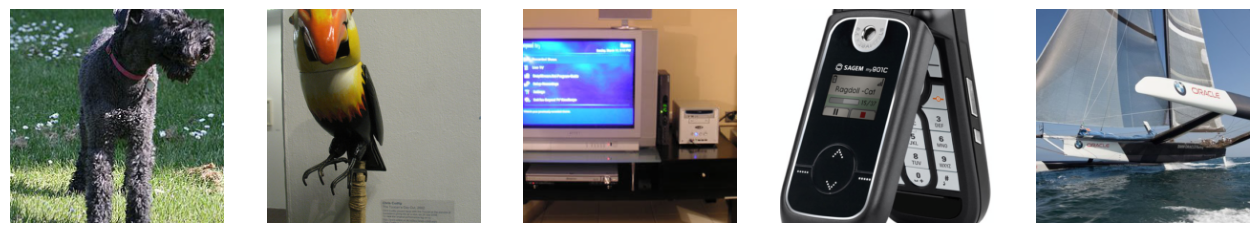

In [2]:
#Please place ImageNet_images.npy, android.csv and your notebook/python file in the same directory; otherwise, change DATA_PATH 
DATA_PATH = ""

#Load 5 images from ImageNet
image_path = os.path.join(DATA_PATH, "ImageNet_images.npy")
host_images = np.load(image_path)

#Plot the data
def plot_digits(instances, images_per_row=5):
    for i in range(len(instances)):
        idx = i % images_per_row
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = np.transpose(instances[i], (1, 2, 0))
        image = std * image + mean
        image = np.clip(image, 0, 1)
        ax[idx].imshow(image)
        ax[idx].axis("off")

fig, ax = plt.subplots(1, 5, figsize=(16, 8))
plot_digits(host_images, images_per_row=5)
plt.show()

def load_android_data(csv_path=DATA_PATH):
    csv_path = os.path.join(csv_path, "android.csv")
    return pd.read_csv(csv_path)

android = load_android_data()

#Divide the data frame into features and labels
android_labels = android["label"].copy() # use "label" as classification label: malicious (1) or benign (0)
android_features = android.drop("label", axis=1) # use API columns other than "label" as features

#Scale the features
std_scaler  = StandardScaler()
android_features_scaled = std_scaler.fit_transform(android_features)

#Feature names include API1 - API329
features = android_features_scaled

#labels - 0: benign; 1: malicious
labels = android_labels.astype(np.int64).to_numpy()
label_names = ['Benign', 'Malicious']

**Select subset of Android app samples and pre-train a logistic regression model from scratch for Android malware detection**

In this task, you will focus on performing adversarial reprogramming for data-limited Android malware detection (with a small number of training samples) and compare it with a logistic regression model trained from scratch; therefore, this logistic regression model is given as follows.

In [3]:
np.random.seed(1)

#To simulate data-limited setting, we only select 100 samples for training and testing
subset_size = 100
sample_indices = np.random.choice(len(labels), subset_size, replace=False)

X = features[sample_indices]
y = labels[sample_indices]

#Data splits: 20% (20 samples) for training and 80% (80 samples) for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.80, random_state=42)

print(X.shape)
print(y.shape)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

#Pre-train a logistic regression for Android malware detection
log_reg = LogisticRegression(solver="lbfgs", random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Android malware detection using a model trained from scratch - Accuracy: %.4f, F1_score: %.4f" % (accuracy, f1))

(100, 329)
(100,)
(20, 329)
(20,)
(80, 329)
(80,)
Android malware detection using a model trained from scratch - Accuracy: 0.6750, F1_score: 0.6577


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

#### Question 1 (10 points):  

**Implement an adversarial reprogramming model to reprogram a high-performing pretrained ImageNet neual network to change the original image classification task to perform data-limited malware detection task, such that the detection performance can be improved over a small training dataset.**

**First, define `InputTransformation` to embed the features from Android apps into the host image, and then implement the function `answer_one( )` to perform input transformation and obtain data loaders for adversarial reprogramming training and testing.**

In [4]:
np.random.seed(42)
feature_size = X_train.shape[1]
index = 0
host_image = host_images[index]
indices = np.random.choice(3 * 224 * 224, feature_size, replace=False)

#Define a clsss InputTransformation to perform input transformation and embed Android features into the host image
class InputTransformation(Dataset):
    def __init__(self, features, labels, host_image, indices, transform=None):
        #Write your code here:
        #Initialize the variables used in the class
        self.features = features
        self.labels = labels
        self.host_image = host_image
        self.indices = indices
        self.transform = transform
    
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        #Write your code here:
        #Extract idx-th Android features from self.features to the variable features
        features = self.features[idx]
        #Write your code here:
        #Extract idx-th Android label from self.labels to the variable label
        label = self.labels[idx]
        #Write your code here:
        #Call copy() to assign a copy of host image from self.host_image to the variable host_image
        host_image = self.host_image.copy()

        #Write your code here:
        #Embed the features of each app into the pixels of host_image specified by self.indices
        host_imageflat = host_image.reshape(-1) # I tried to see if this would work instead of hard coding the indices. There wasn't a difference in performance.
        host_imageflat[self.indices] = features
        host_image = host_imageflat.reshape(host_image.shape)
        

        sample = {'image': host_image, 'label': label}
        if self.transform:
            sample = self.transform(sample)

        return sample

    
def answer_one():
    #Write your code here:
    #Call InputTransformation() to construct train_dataset that transform (X_train, y_train) to images
    #Note: InputTransformation() requires 5 parameters. Please check the defined class InputTransformation
    #Note: ToTensor() needs to be used via the last parameter "transform" to convert the data to torch tensors 
    train_dataset = InputTransformation(X_train, y_train, host_image, indices, transform=ToTensor())
    
    #Write your code here:
    #Call DataLoader() to load train_dataset into DataLoader (batch_size should be small <10 and shuffle needs to be true)
    train_dataloader = DataLoader(train_dataset, batch_size=5, shuffle=True)
    
    #Write your code here:
    #Call InputTransformation() to construct test_dataset that transform (X_test, y_test) to images
    #Note: InputTransformation() requires 5 parameters. Please check the defined class InputTransformation
    #Note: ToTensor() needs to be used via the last parameter "transform" to convert the data to torch tensors  
    test_dataset = InputTransformation(X_test, y_test, host_image, indices, transform=ToTensor())
    
    #Write your code here:
    #Call DataLoader() to load test_dataset into DataLoader (Specify batch_size and shuffle needs to be false)
    test_dataloader = DataLoader(test_dataset, batch_size=5, shuffle=False)
    
    return train_dataloader, test_dataloader

#Run your function in the cell to return the results
train_dataloader, test_dataloader = answer_one()

#### <font color='red'>Answer 1 (double click here to answer the questions in this cell):</font>  
Based on the implemented steps in this question: 
- Briefly summarize why the input transformation is necessary for reprogramming pretrained ImageNet neural network: ( The input transformation is needed because the ImageNet model only knows how to read images not malware feature vectors. By embedding the Android app features directly into a host image, we convert the malware data into something the pretrained network can interpret. This lets the model use its existing visual features to separate malicious and benign samples even though it was never trained for security tasks. Since only the transformation is learned and not the whole network, we can get good performance even with a very small malware dataset. )

#### Question 2 (10 points):  

**First, define `AdversarialReprogrammingNet` to complete adversarial reprogramming operations, and then implement the function `answer_two( )` to train the adversarial reprogramming model and evaluate its performance for malware detection, which reads in the transformed inputs (i.e., images with app features), adds perturbation into the inputs, calculates the image classification results using the pretrained ImageNet neural network, and maps these image classfication results (1,000 classes) to the malware detection results (either benign or malicious).** 

In [ ]:
torch.manual_seed(1)
epochs = 5
learning_rate = 0.001
weight_decay = 5e-4
lossfunction = nn.CrossEntropyLoss()

pretrained_model = models.densenet161(pretrained=True)
pretrained_model.eval()
for param in pretrained_model.parameters():
    param.requires_grad = False
    
#Define a clsss AdversarialReprogrammingNet to perform adversarial reprogramming
class AdversarialReprogrammingNet(nn.Module):
    def __init__(self, pretrained_model):
        super(AdversarialReprogrammingNet, self).__init__()
        #Write your code here:
        #Select class 0 and class 1 from ImageNet class space to predict benign and malicious, respectively
        self.hard_coded_idx = [0, 1]
        #Write your code here:
        #Set up the pretrained model
        self.pretrained_model = pretrained_model
        #Write your code here:
        #Create a 3x224x224-dimensional perturbation tensor and add it to the model parameter (requires_grad needs to be True)
        self.perturbation = Parameter(torch.FloatTensor(3, 224, 224), requires_grad=True)
        
        self.reset_parameter()
    
    def reset_parameter(self):
        stdv = 1. / math.sqrt(self.perturbation.size(1))
        self.perturbation.data.uniform_(-stdv, stdv)
    
    def forward(self, x):
        #Write your code here:
        #Add the perturbation to the input x
        x = x + self.perturbation
        #Write your code here:
        #Feed the perturbed x to the pretrained model to get image classification results 
        x = self.pretrained_model(x)
        #Write your code here:
        #Map the image classification results to the malware detection results using hard-coded mapping
        y = x[:, self.hard_coded_idx]
        
        return y
    

def answer_two():
    #Write your code here:
    #Instantiate an adversarial reprogramming model from the defined AdversarialReprogrammingNet (need to pass a corresponding parameter)
    adversarial_reprogramming_model = AdversarialReprogrammingNet(pretrained_model)
    
    parameter_to_update = []
    for p in adversarial_reprogramming_model.parameters():
        if p.requires_grad:
            parameter_to_update.append(p)
            break
    
    #Write your code here:
    #Specify the Adam optimizer (parameter_to_update, learning rate, and weight decay) used for model training via gradient descent
    adversarial_reprogramming_optimizer = optim.Adam(parameter_to_update, lr=learning_rate, weight_decay=weight_decay)
    
    print("-------Train the adversarial reprogramming model-------")
    for epoch in range(1, epochs + 1):
        #Write your code here:
        #Call train() function for adversarial_reprogramming_model training
        #Note: you need to pass the corresponding parameters to this function
        train(epoch, adversarial_reprogramming_model, train_dataloader, adversarial_reprogramming_optimizer, lossfunction)
    
    print("-------Test the adversarial reprogramming model-------")
    #Write your code here:
    #Call test() function for testing adversarial_reprogramming_model
    #Note: you need to pass the corresponding parameters to this function
    test(adversarial_reprogramming_model, test_dataloader)

#Run your function in the cell to return the results
answer_two()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet161_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet161_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


-------Train the adversarial reprogramming model-------
epoch (1): Train accuracy: 0.6000, loss: 0.124
epoch (2): Train accuracy: 0.8000, loss: 0.066
epoch (3): Train accuracy: 0.8000, loss: 0.065
epoch (4): Train accuracy: 0.9000, loss: 0.042
epoch (5): Train accuracy: 0.9500, loss: 0.039
-------Test the adversarial reprogramming model-------


#### <font color='red'>Answer 2 (double click here to answer the questions in this cell):</font>  
In this question, only 20 training samples are used for malware detection model training<br>
- When training a logistic regression from scratch, the test accuracy is: ( 0.6750 ) <br>
- When training an adversarial reprogranmming model, the test accuracy is: ( 0.7625 ) <br>
- Comparing these test performances, please describe your observation: ( What I observed was that the adversarial reprogramming model performs better than logistic regression. Logistic regression gets about 67% accuracy while the reprogramming model reaches about 76%. This shows that the pretrained ImageNet network can make better use of the small training set once the malware features are embedded into images. ) <br>
- And explain why adversarial reprogramming can deliver such a performance difference: ( Adversarial reprogramming works better because it builds on the pretrained ImageNet model. Here the model already has strong feature extraction abilities so it does not need many malware samples to learn the task. The perturbation guides the network to interpret the embedded malware features and map them to benign or malicious labels. Logistic regression does not have this deep feature knowledge and struggles with very limited data. )

## <font color='blue'>Membership Inference Attack</font>

In Question 3, Question 4, and Question 5, you will continue using the `Android dataset` to perform membership inference attack.

#### Prepare Datasets and train a target model

For the membership inference attack introduced in class, the first step is to synthesize a dataset to train a shadow (surrogate) model. Here, instead of sythesizing the dataset, you will sample this dataset directly from the loaded data (`features`, `labels`) and focus on the second step that trains a set of shadow models to collect member and non-member confidence scores and construct the final membership inference attack model.

We also train a logistic regression model here as the target model. After this target model is trained, a membership inference attack will be built to infer if a data sample is used to train this target model or not.

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

#Data splits: (M_X_train, M_y_train) for target model, and (M_X_test, M_y_test) for shadow models
M_X_train, M_X_test, M_y_train, M_y_test = train_test_split(features, labels, test_size=0.50, random_state=42)

#The number of shadow models
num_shadow_models = 10

#The size of samples for each shadow model
shadow_size = 200

#List of training datasets: each training set is used to train one shadow model
list_shadow_features = []
list_shadow_labels = []
#List of Unseen datasets: one for each shadow model
list_unseen_features = []

for _ in range(num_shadow_models):
    #training data and unseen data should be disjoint
    #Obtain the indices for training data and unseen data
    train_indices = np.random.choice(len(M_X_test), shadow_size, replace=False)
    remaining_indices = np.setdiff1d(np.arange(len(M_X_test)), train_indices)
    unseen_indices = np.random.choice(remaining_indices, shadow_size, replace=False)
    
    subset_train_features = M_X_test[train_indices]
    subset_train_labels = M_y_test[train_indices]
    subset_unseen_features = M_X_test[unseen_indices]
    
    list_shadow_features.append(subset_train_features)
    list_shadow_labels.append(subset_train_labels)
    list_unseen_features.append(subset_unseen_features)

#Train a target model
target_model = LogisticRegression(solver="newton-cg", random_state=42)
target_model.fit(M_X_train, M_y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:721: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


#### Question 3 (10 points):  

**Implement the function `answer_three( )` to collect `total_members` and `total_non_members` for attack model training, where `total_members` are confidence scores of samples used by shadow model training, and `total_non_members` are confidence scores of samples unseen to shadow models. You can use the pre-defined function `make_member_nonmember( )` to obtain `member_set` and `non_member_set` for a given shadow model. Please train a set of shadow models to aggregate all these data sets.**

In [ ]:
def answer_three():    
    total_members = []
    total_non_members = []
    
    for shadow_number, shadow_features in enumerate(list_shadow_features):
        print("-----------Shadow model: {}-----------".format(shadow_number + 1))
        shadow_labels = list_shadow_labels[shadow_number]
        unseen_features = list_unseen_features[shadow_number]

        #Write your code here:
        #Define a shadow_model using LogisticRegression() from scikit-learn library
        #Call fit() to train shadow_model using shadow_features and shadow_labels
        shadow_model = LogisticRegression(solver="newton-cg", random_state=42)
        shadow_model.fit(shadow_features, shadow_labels)

        #Write your code here:
        #Call make_member_nonmember() to create member_set vs non_member_set based on shadow_model
        #Note: member_set should be from shadow_features and non_member_set should be from unseen_features
        member_set, non_member_set = make_member_nonmember(shadow_model, shadow_features, unseen_features)

        #Write your code here:
        #Append member_set to total_members
        #Append non_member_set to total_non_members
        total_members.append(member_set)
        total_non_members.append(non_member_set)
        
    total_members = np.concatenate(total_members)
    total_non_members = np.concatenate(total_non_members)
    
    return total_members, total_non_members

#Run your function in the cell to return the results
total_members, total_non_members = answer_three()
print("Total members: ", total_members)
print("Total non-members: ", total_non_members)

-----------Shadow model: 1-----------
-----------Shadow model: 2-----------
-----------Shadow model: 3-----------
-----------Shadow model: 4-----------
-----------Shadow model: 5-----------
-----------Shadow model: 6-----------
-----------Shadow model: 7-----------
-----------Shadow model: 8-----------
-----------Shadow model: 9-----------
-----------Shadow model: 10-----------
Total members:  [[0.99882793 0.00117207]
 [0.04065274 0.95934726]
 [0.05113819 0.94886181]
 ...
 [0.00560199 0.99439801]
 [0.0252684  0.9747316 ]
 [0.93258289 0.06741711]]
Total non-members:  [[9.99998208e-01 1.79181898e-06]
 [6.77425538e-01 3.22574462e-01]
 [7.22759347e-01 2.77240653e-01]
 ...
 [9.92346629e-01 7.65337075e-03]
 [3.03908609e-06 9.99996961e-01]
 [9.91894823e-01 8.10517679e-03]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:721: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

#### <font color='red'>Answer 3 (double click here to answer the questions in this cell):</font>  
Based on the implemented steps in this question:
- Briefly summarize the difference between member sets and non-member sets: ( Member sets contain confidence scores for samples that were used to train the shadow model. Non member sets contain confidence scores for samples that the shadow model never saw. The member set shows how the model behaves on data it learned from. While the non member set shows how the model behaves on unseen data. )
- Explain why this difference exists ( The difference exists because trained models tend to be more confident on samples they saw during training. These samples fit the learned decision boundary. Unseen samples often look slightly different from what the model learned, so the model gives lower and less stable confidence scores. This gap appears naturally and it becomes the signal that the membership inference attack learns to use. )

#### Question 4 (10 points): 

**Implement the function `answer_four( )` to train a binary classification model as membership inference attack model using `total_members` and `total_non_members`, and evaluate its attack performance.**

In [ ]:
def answer_four():
    total_members_size = total_members.shape[0]
    total_non_members_size = total_non_members.shape[0]
    total_members_labels = np.repeat(1, total_members_size)
    total_non_members_labels = np.repeat(0, total_non_members_size)

    #Write your code here:
    #Call np.concatenate() to join (total_members, total_non_members) to construct X_attack
    #Call np.concatenate() to join (total_members_labels, total_non_members_labels) to construct y_attack
    X_attack = np.concatenate((total_members, total_non_members), axis=0)
    y_attack = np.concatenate((total_members_labels, total_non_members_labels), axis=0)

    #Write your code here:
    #Call train_test_split() to split data (X_attack, y_attack) to training data for attack model training and test data for attack model evaluation
    #Note: 80% for training and 20% for testing
    X_attack_train, X_attack_test, y_attack_train, y_attack_test = train_test_split(X_attack, y_attack, test_size=0.20, random_state=42)

    #Write your code here:
    #Define an attack_model using LogisticRegression() from scikit-learn library
    attack_model = LogisticRegression(solver="newton-cg", random_state=42)
    #Call fit() to train attack_model using X_attack_train and y_attack_train
    attack_model.fit(X_attack_train, y_attack_train)
    #Use the trained attack_model to predict on X_attack_test to get y_attack_pred
    y_attack_pred = attack_model.predict(X_attack_test)
    #Use y_attack_test and y_attack_pred to calculate accuracy and F1 score using sklearn functions    
    accuracy = accuracy_score(y_attack_test, y_attack_pred)
    f1 = f1_score(y_attack_test, y_attack_pred, average='macro')
    
    return accuracy, f1, attack_model

#Run your function in the cell to return the results
accuracy, f1, attack_model = answer_four()
print("Accuracy: ", accuracy)
print("F1 score: ", f1)

Accuracy:  0.52875
F1 score:  0.5287492636707245


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Libr

#### <font color='red'>Answer 4 (double click here to answer the questions in this cell):</font>  
When training a binary classification model to perform membership inference attack on the shadow models: <br>
- The test accuracy is: ( 0.52875 ) <br>
- The f1-score is: ( 0.528749 )

#### Question 5 (10 points): 

**Implement the function `answer_five( )` to use the trained attack model `attack_model` to perform membership inference attack over the target model `target_model`. In Question 4, `attack_model` is only evaluated on the dataset generated from the shadow models, but in the real-world setting, this attack model needs to be applied to infer the membership of a black-box `target_model`. As `target_model` is trained on `M_X_train`, you can feed `M_X_train` to `target_model` to collect probability outputs as member set; as `M_X_test` is unseen to `target_model`, then you can feed `M_X_test` to `target_model` to collect propability outputs as non-member set.**

In [ ]:
def answer_five():
    #Write your code here:
    #Call make_member_nonmember() to create member_set vs non_member_set based on target_model
    #Note: model should be target_model, member_set should be from M_X_train and non_member_set should be from M_X_test
    member_set, non_member_set = make_member_nonmember(target_model, M_X_train, M_X_test)
    
    members_size = member_set.shape[0]
    non_members_size = non_member_set.shape[0]
    members_labels = np.repeat(1, members_size)
    non_members_labels = np.repeat(0, non_members_size)
    
    #Write your code here:
    #Call np.concatenate() to join (member_set, non_member_set) to construct X_membership
    #Call np.concatenate() to join (members_labels, non_members_labels) to construct y_membership
    X_membership = np.concatenate((member_set, non_member_set), axis=0)
    y_membership = np.concatenate((members_labels, non_members_labels), axis=0)

    #Write your code here:
    #Use attack_model to predict on X_membership to get y_pred_membership
    y_pred_membership = attack_model.predict(X_membership)

    #Write your code here:
    #Use y_membership and y_pred_membership to calculate accuracy and F1 score using sklearn functions
    accuracy = accuracy_score(y_membership, y_pred_membership)
    f1 = f1_score(y_membership, y_pred_membership, average='macro')
    
    return accuracy, f1

#Run your function in the cell to return the results
accuracy, f1 = answer_five()
print("Accuracy: ", accuracy)
print("F1 score: ", f1)

Accuracy:  0.5072463768115942
F1 score:  0.5064376200768492


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

#### <font color='red'>Answer 5 (double click here to answer the questions in this cell):</font>  
When using the attack model trained on the data collected from shadow models to perform membership inference attack over the target model: <br>
- The test accuracy is: ( 0.50724 ) and the f1-score is: ( 0.50643 )

Comparing the attack performances in Question 4 and 5: 
- Describe your observation: ( The attack performs slightly worse on the target model than it did on the shadow model data. The accuracy drops close to chance level and the f1 score also drops which shows that the attack model struggles to separate member and non member samples once it is applied to the real target. ) <br>
- Explain why this difference exists: ( This happens because the attack model learns only from the confidence patterns of the shadow models. Those patterns are not the same as the patterns of the true target model since the shadow models are trained on different data. When the attack model is used on the real target the confidence signals no longer match what it learned, the gap between member and non member samples becomes smaller and the overall attack performance drops. )